# Seasonal Agriculture Performance Analysis

**VOIS AICTE Major Project — Data Visualization / Data Analytics**


In [9]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from google.colab import drive
drive.mount('/content/drive/')
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


## 1. Load the dataset

In [10]:

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/seasonal_agriculture_performance_dataset.csv")
print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Dataset loaded successfully.
Rows: 4000
Columns: 28


In [11]:
# First five records
df.head()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [12]:
# Dataset structure
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [13]:
# Descriptive statistics
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.00,7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,3952.00,601.15,288.93,80.00,370.20,582.00,834.95,1395.20
Avg_Temperature_C,4000.00,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,4000.00,63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,4000.00,7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,4000.00,6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,3960.00,26.51,6.71,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,4000.00,120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,4000.00,57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,4000.00,104.76,27.74,30.00,86.20,105.10,123.60,200.00


## 2. Data quality and cleaning

In [14]:
# Check missing values
missing = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (df.isna().sum() / len(df) * 100).round(2)
})

missing[missing["Missing_Count"] > 0].sort_values("Missing_Count", ascending=False)


,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


In [15]:
# Check duplicate records
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)


Duplicate rows: 0


In [16]:
# Remove exact duplicate rows, if any
clean_df = df.drop_duplicates().copy()

print("Original shape:", df.shape)
print("Cleaned shape:", clean_df.shape)


Original shape: (4000, 28)
Cleaned shape: (4000, 28)


In [17]:
# Check data types
clean_df.dtypes


,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [18]:
# Convert categorical columns to category type
categorical_columns = [
    "State", "District", "Crop", "Season", "Irrigation_Method"
]

for column in categorical_columns:
    clean_df[column] = clean_df[column].astype("category")

clean_df[categorical_columns].dtypes


,0
State,category
District,category
Crop,category
Season,category
Irrigation_Method,category


In [19]:
# Check category values
for column in categorical_columns:
    print("\n", "=" * 50)
    print(column)
    print("=" * 50)
    print(clean_df[column].value_counts())



State
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

District
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

Crop
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Season
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Irrigation_Method
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


In [20]:
# Check negative values in numerical columns
numeric_columns = clean_df.select_dtypes(include=np.number).columns

negative_values = {
    column: int((clean_df[column] < 0).sum())
    for column in numeric_columns
    if (clean_df[column] < 0).sum() > 0
}

print("Negative-value counts:", negative_values)


Negative-value counts: {'Profit_INR': 1966}


### Missing-value treatment

The dataset contains missing values in **Rainfall_mm, Soil_Moisture_pct and Yield_Tonnes_Ha**.  
For descriptive analysis, pandas aggregation functions ignore missing observations automatically. We therefore retain valid observations instead of blindly deleting rows. For analyses that specifically require Yield, the code below uses non-missing Yield observations.

This keeps the analysis transparent and avoids unnecessary loss of data.


## 3. Basic exploratory analysis

In [21]:
# Dataset dimensions and category counts
print("Number of farms:", clean_df["Farm_ID"].nunique())
print("States:", clean_df["State"].nunique())
print("Districts:", clean_df["District"].nunique())
print("Crops:", clean_df["Crop"].nunique())
print("Seasons:", clean_df["Season"].nunique())
print("Irrigation methods:", clean_df["Irrigation_Method"].nunique())


Number of farms: 4000
States: 8
Districts: 10
Crops: 8
Seasons: 3
Irrigation methods: 4


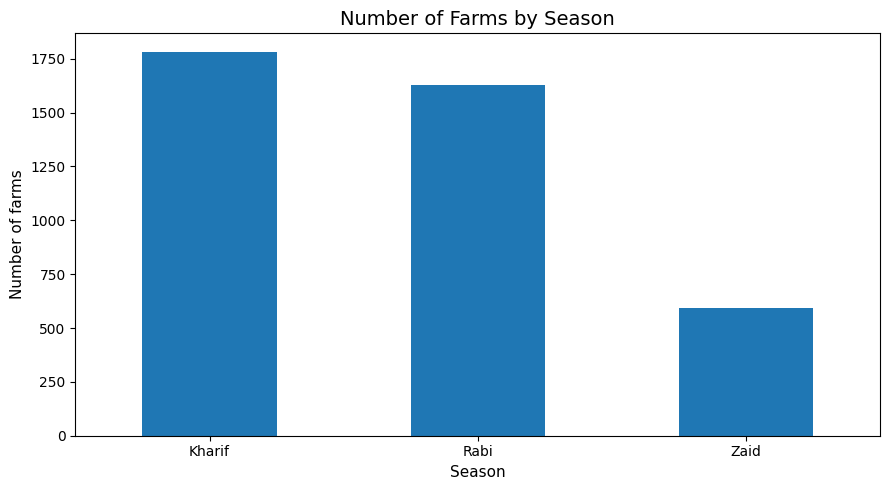

In [22]:
# Season distribution
season_counts = clean_df["Season"].value_counts()

plt.figure()
season_counts.plot(kind="bar")
plt.title("Number of Farms by Season")
plt.xlabel("Season")
plt.ylabel("Number of farms")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


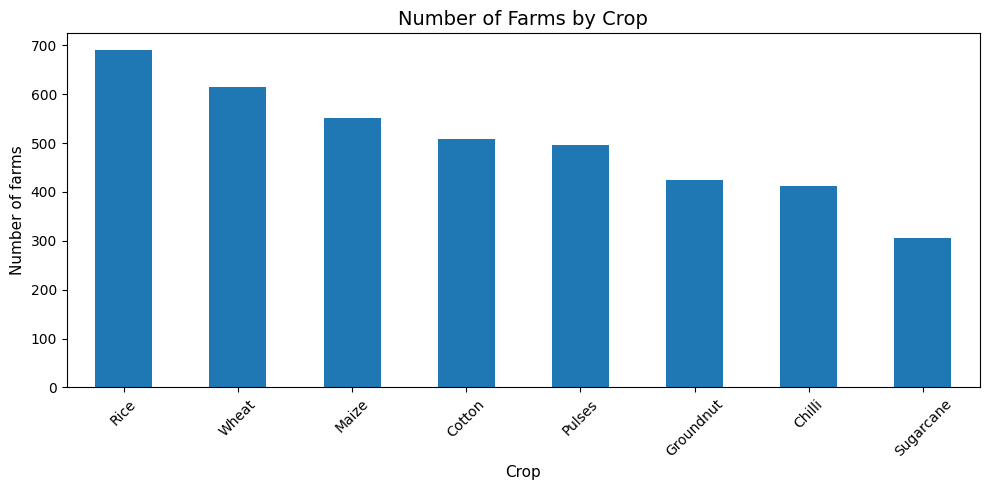

In [23]:
# Crop distribution
crop_counts = clean_df["Crop"].value_counts()

plt.figure(figsize=(10, 5))
crop_counts.plot(kind="bar")
plt.title("Number of Farms by Crop")
plt.xlabel("Crop")
plt.ylabel("Number of farms")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


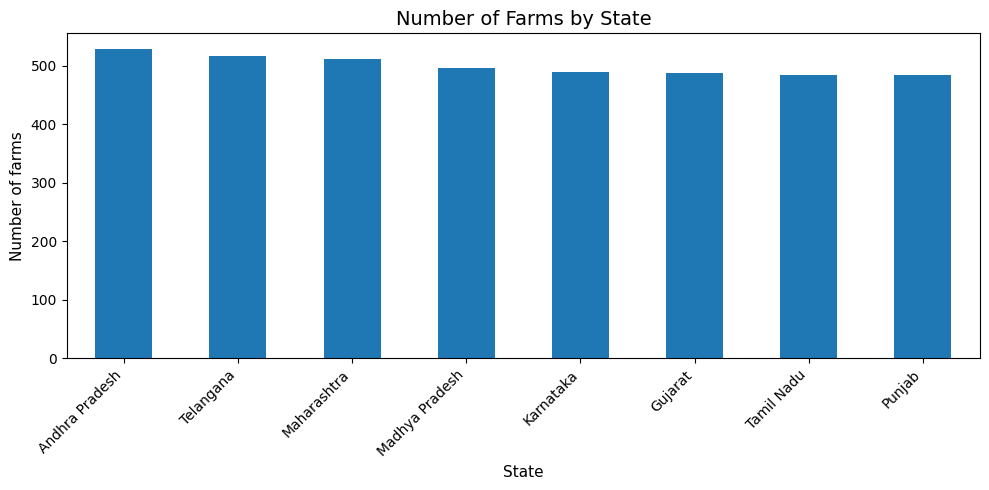

In [24]:
# State distribution
state_counts = clean_df["State"].value_counts()

plt.figure(figsize=(10, 5))
state_counts.plot(kind="bar")
plt.title("Number of Farms by State")
plt.xlabel("State")
plt.ylabel("Number of farms")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 4. Seasonal performance analysis

In [25]:
# Put seasons in logical order
season_order = ["Kharif", "Rabi", "Zaid"]

clean_df["Season"] = pd.Categorical(
    clean_df["Season"],
    categories=season_order,
    ordered=True
)

season_summary = clean_df.groupby("Season", observed=True).agg(
    Farms=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Production=("Production_Tonnes", "mean"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Cost=("Total_Cost_INR", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water=("Water_Used_m3", "mean"),
    Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Rainfall=("Rainfall_mm", "mean"),
    Temperature=("Avg_Temperature_C", "mean"),
    Disease_Pest_Risk=("Disease_Pest_Risk_pct", "mean")
)

season_summary


,Farms,Average_Yield,Average_Production,Average_Revenue,Average_Cost,Average_Profit,Average_Water,Water_Efficiency,Rainfall,Temperature,Disease_Pest_Risk
Season,,,,,,,,,,,
Kharif,1779,5.64,46.31,710719.06,531804.41,178914.65,6102.20,5.89,852.08,28.45,54.47
Rabi,1627,5.08,41.49,601526.05,513836.58,87689.47,5846.99,5.19,436.00,23.49,40.48
Zaid,594,4.67,38.89,519171.90,543976.73,-24804.82,6419.89,4.41,299.42,31.04,38.22


In [26]:
# Profitability percentage by season
positive_profit = (
    clean_df.groupby("Season", observed=True)["Profit_INR"]
    .apply(lambda x: (x > 0).mean() * 100)
)

print("Percentage of farms with positive profit:")
print(positive_profit.round(2))


Percentage of farms with positive profit:
Season
Kharif   57.79
Rabi     48.86
Zaid     35.52
Name: Profit_INR, dtype: float64


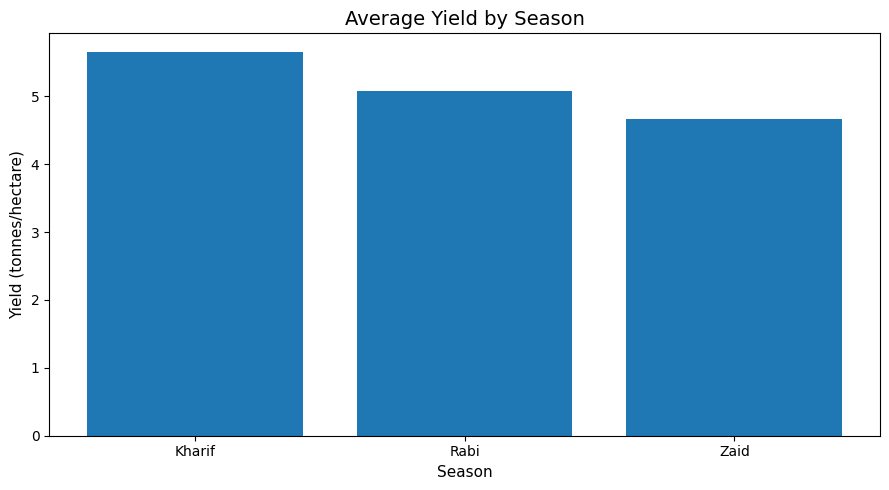

In [27]:
# Seasonal yield comparison
plt.figure()
plt.bar(season_summary.index.astype(str), season_summary["Average_Yield"])
plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Yield (tonnes/hectare)")
plt.tight_layout()
plt.show()


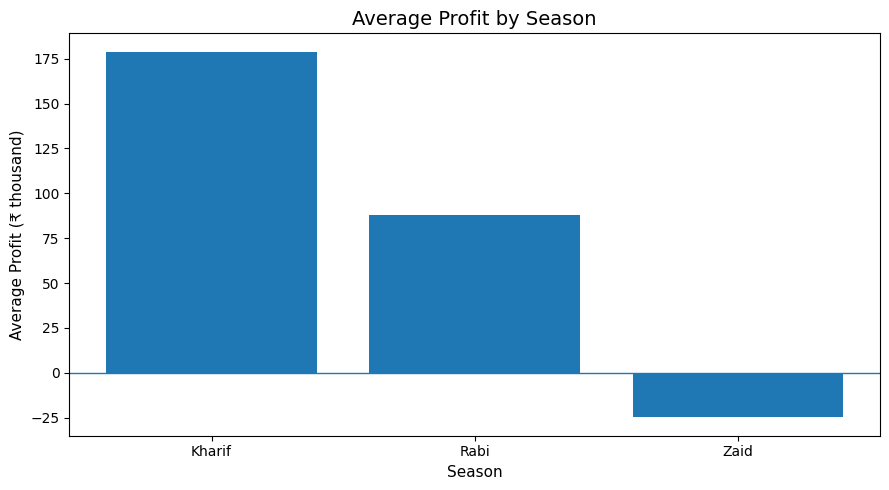

In [28]:
# Seasonal profit comparison
plt.figure()
plt.bar(season_summary.index.astype(str), season_summary["Average_Profit"] / 1000)
plt.axhline(0, linewidth=1)
plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (₹ thousand)")
plt.tight_layout()
plt.show()


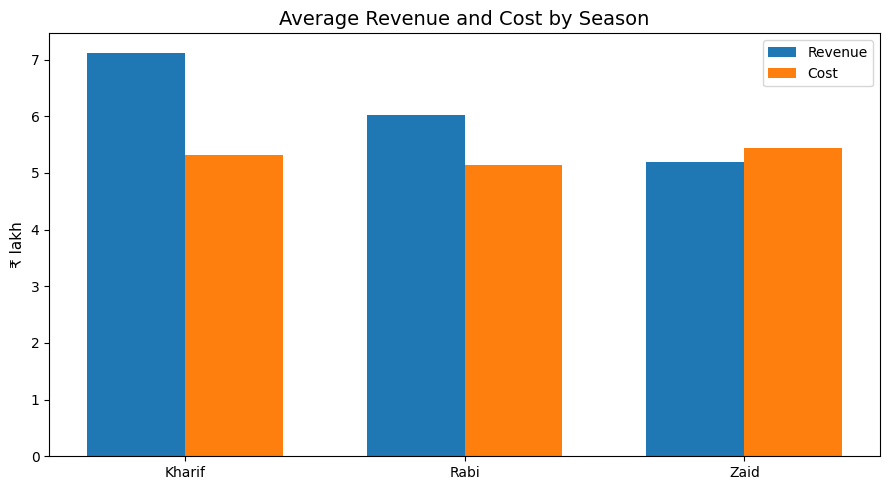

In [29]:
# Revenue versus cost
x = np.arange(len(season_summary))
width = 0.35

plt.figure()
plt.bar(x - width/2, season_summary["Average_Revenue"] / 100000, width, label="Revenue")
plt.bar(x + width/2, season_summary["Average_Cost"] / 100000, width, label="Cost")
plt.xticks(x, season_summary.index.astype(str))
plt.ylabel("₹ lakh")
plt.title("Average Revenue and Cost by Season")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Irrigation method analysis

In [30]:
irrigation_summary = clean_df.groupby("Irrigation_Method").agg(
    Farms=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water=("Water_Used_m3", "mean"),
    Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).sort_values("Average_Profit", ascending=False)

irrigation_summary


/tmp/ipykernel_2854/2152184956.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  irrigation_summary = clean_df.groupby("Irrigation_Method").agg(


,Farms,Average_Yield,Average_Profit,Average_Water,Water_Efficiency
Irrigation_Method,,,,,
Drip,915,6.62,219626.00,5918.75,6.27
Sprinkler,734,5.19,91121.08,6208.26,4.67
Rainfed,1041,4.61,79050.37,3549.55,7.56
Flood,1310,4.90,73354.02,8026.47,3.44


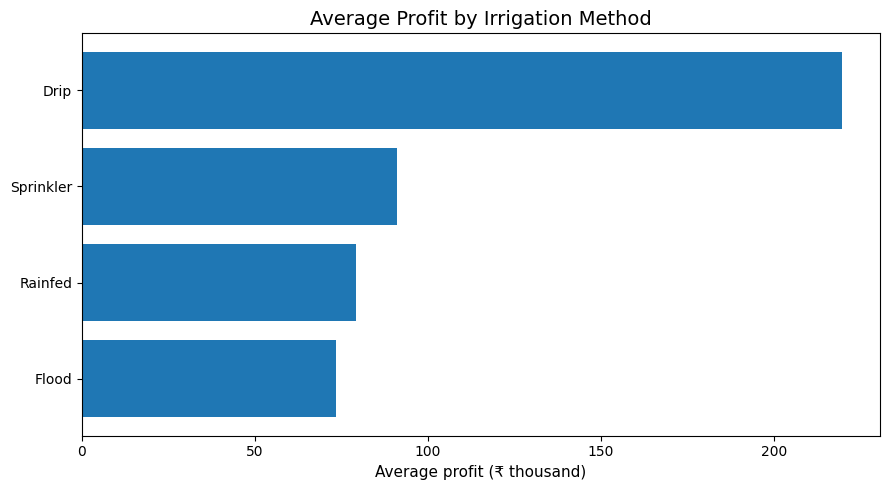

In [31]:
# Average profit by irrigation method
plt.figure()
plt.barh(
    irrigation_summary.index.astype(str),
    irrigation_summary["Average_Profit"] / 1000
)
plt.gca().invert_yaxis()
plt.xlabel("Average profit (₹ thousand)")
plt.title("Average Profit by Irrigation Method")
plt.tight_layout()
plt.show()


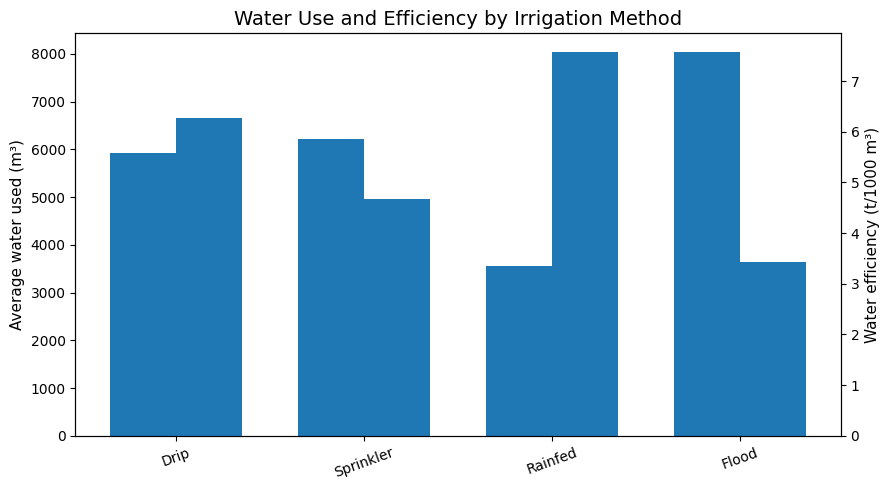

In [32]:
# Water use and water efficiency by irrigation method
x = np.arange(len(irrigation_summary))
width = 0.35

fig, ax1 = plt.subplots()
ax1.bar(x - width/2, irrigation_summary["Average_Water"], width, label="Water used (m³)")
ax1.set_ylabel("Average water used (m³)")
ax1.set_xticks(x, irrigation_summary.index.astype(str), rotation=20)

ax2 = ax1.twinx()
ax2.bar(x + width/2, irrigation_summary["Water_Efficiency"], width, label="Water efficiency")
ax2.set_ylabel("Water efficiency (t/1000 m³)")

plt.title("Water Use and Efficiency by Irrigation Method")
plt.tight_layout()
plt.show()


## 6. Crop × season analysis

In [33]:
crop_season_profit = clean_df.pivot_table(
    index="Crop",
    columns="Season",
    values="Profit_INR",
    aggfunc="mean"
).reindex(columns=season_order)

crop_season_profit


/tmp/ipykernel_2854/4004183217.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  crop_season_profit = clean_df.pivot_table(


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,954380.42,638572.50,448659.09
Cotton,216999.55,107343.59,-53925.34
Groundnut,108265.44,10416.54,-68872.50
Maize,-39332.67,-89133.40,-194049.17
Pulses,43338.90,-14309.14,-139227.81
Rice,-64903.40,-98427.87,-227239.34
Sugarcane,1000790.81,731612.86,583635.80
Wheat,-105871.87,-119954.57,-193208.95


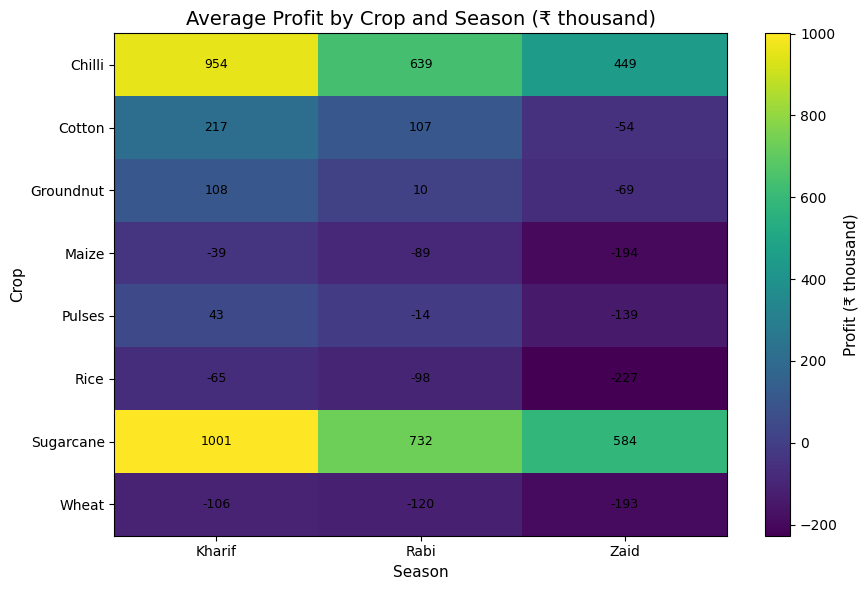

In [34]:
# Crop-season profit heatmap using matplotlib
matrix = crop_season_profit.values / 1000

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(matrix, aspect="auto")

ax.set_xticks(range(len(crop_season_profit.columns)))
ax.set_xticklabels(crop_season_profit.columns.astype(str))
ax.set_yticks(range(len(crop_season_profit.index)))
ax.set_yticklabels(crop_season_profit.index)

ax.set_xlabel("Season")
ax.set_ylabel("Crop")
ax.set_title("Average Profit by Crop and Season (₹ thousand)")

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        if not np.isnan(matrix[i, j]):
            ax.text(j, i, f"{matrix[i,j]:.0f}", ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax, label="Profit (₹ thousand)")
plt.tight_layout()
plt.show()


In [35]:
# Find best and worst crop-season combinations
crop_season_long = (
    clean_df.groupby(["Season", "Crop"], observed=True)["Profit_INR"]
    .mean()
    .reset_index()
)

best_combination = crop_season_long.loc[crop_season_long["Profit_INR"].idxmax()]
worst_combination = crop_season_long.loc[crop_season_long["Profit_INR"].idxmin()]

print("Best crop-season combination:")
print(best_combination)

print("\nWorst crop-season combination:")
print(worst_combination)


Best crop-season combination:
Season           Kharif
Crop          Sugarcane
Profit_INR   1000790.81
Name: 6, dtype: object

Worst crop-season combination:
Season             Zaid
Crop               Rice
Profit_INR   -227239.34
Name: 21, dtype: object


## 7. State-wise analysis

In [36]:
state_summary = clean_df.groupby("State").agg(
    Farms=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Profit=("Profit_INR", "mean")
).sort_values("Average_Profit", ascending=False)

state_summary


/tmp/ipykernel_2854/1463272326.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  state_summary = clean_df.groupby("State").agg(


,Farms,Average_Yield,Average_Revenue,Average_Profit
State,,,,
Punjab,484,6.12,686225.70,136025.64
Maharashtra,512,5.03,650032.67,135428.86
Karnataka,489,5.73,653426.18,119422.34
Tamil Nadu,485,4.90,629093.42,117744.75
Gujarat,488,5.70,654692.86,117568.24
Telangana,516,5.08,628784.53,108829.62
Madhya Pradesh,497,5.03,597558.36,86840.76
Andhra Pradesh,529,4.65,606663.66,73453.53


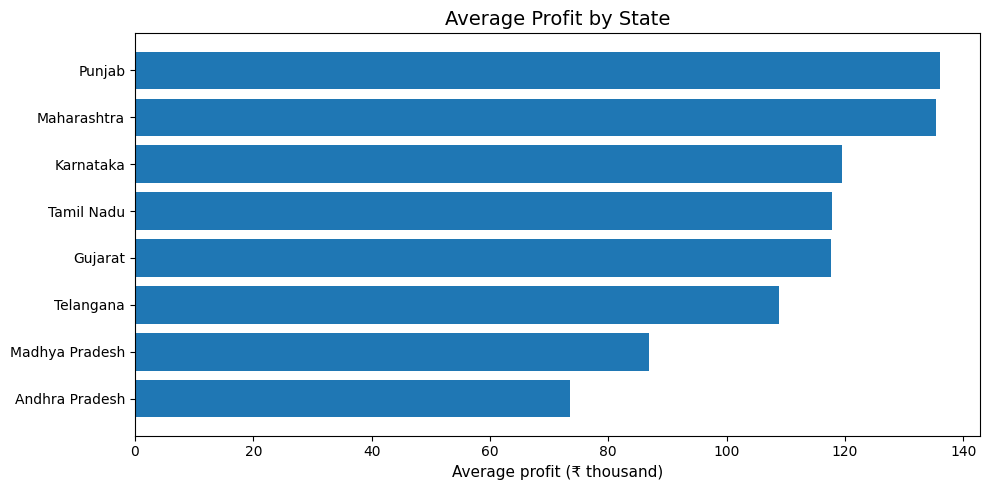

In [37]:
# State-wise average profit
plt.figure(figsize=(10, 5))
plt.barh(
    state_summary.index,
    state_summary["Average_Profit"] / 1000
)
plt.gca().invert_yaxis()
plt.xlabel("Average profit (₹ thousand)")
plt.title("Average Profit by State")
plt.tight_layout()
plt.show()


## 8. Environmental and risk analysis

In [38]:
# Seasonal environmental conditions
environment_summary = clean_df.groupby("Season", observed=True).agg(
    Rainfall_mm=("Rainfall_mm", "mean"),
    Temperature_C=("Avg_Temperature_C", "mean"),
    Humidity_pct=("Humidity_pct", "mean"),
    Soil_Moisture_pct=("Soil_Moisture_pct", "mean"),
    Disease_Pest_Risk_pct=("Disease_Pest_Risk_pct", "mean")
)

environment_summary


,Rainfall_mm,Temperature_C,Humidity_pct,Soil_Moisture_pct,Disease_Pest_Risk_pct
Season,,,,,
Kharif,852.08,28.45,71.81,31.20,54.47
Rabi,436.00,23.49,57.89,24.05,40.48
Zaid,299.42,31.04,52.01,19.17,38.22


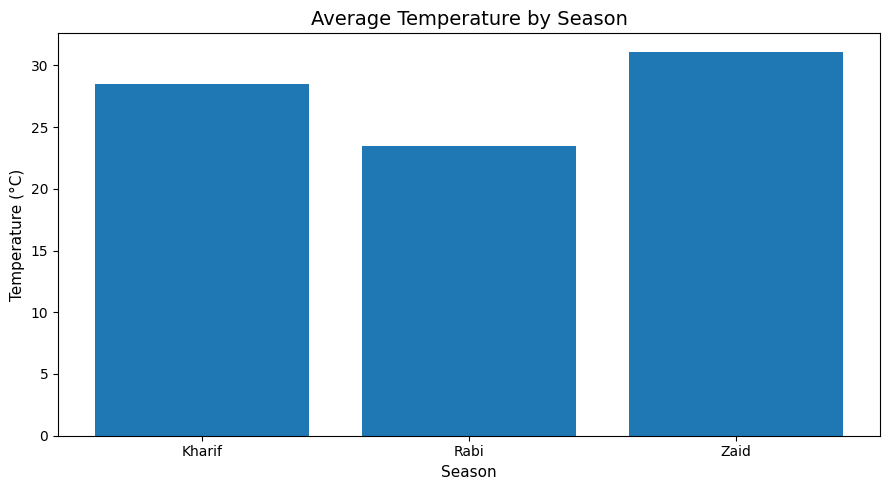

In [39]:
# Temperature by season
plt.figure()
plt.bar(environment_summary.index.astype(str), environment_summary["Temperature_C"])
plt.title("Average Temperature by Season")
plt.xlabel("Season")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()


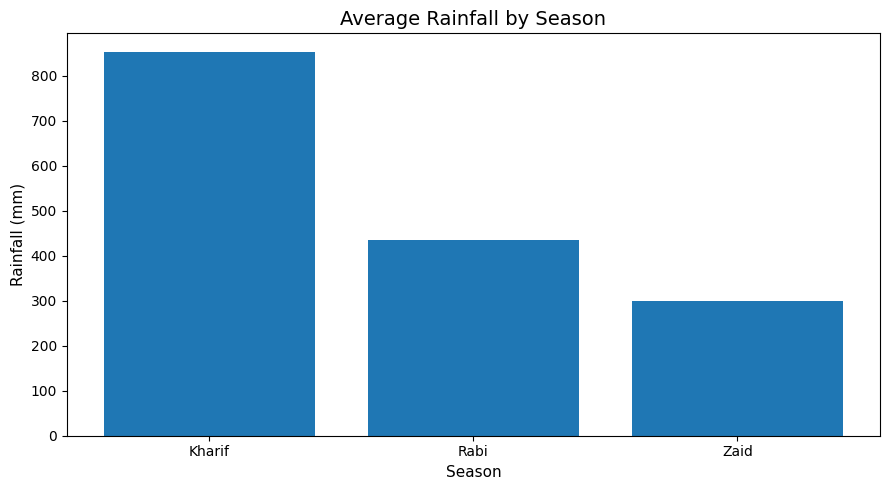

In [40]:
# Rainfall by season
plt.figure()
plt.bar(environment_summary.index.astype(str), environment_summary["Rainfall_mm"])
plt.title("Average Rainfall by Season")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")
plt.tight_layout()
plt.show()


## 9. Correlation analysis

In [41]:
# Correlation of numerical variables with profit
correlation_with_profit = (
    clean_df.select_dtypes(include=np.number)
    .corr()["Profit_INR"]
    .sort_values(ascending=False)
)

correlation_with_profit


,Profit_INR
Profit_INR,1.00
Revenue_INR,0.89
Production_Tonnes,0.55
Yield_Tonnes_Ha,0.49
Water_Efficiency_t_per_1000m3,0.49
Market_Price_INR_Tonne,0.23
Water_Used_m3,0.19
Farm_Area_Hectares,0.12
Rainfall_mm,0.11
Soil_Moisture_pct,0.09


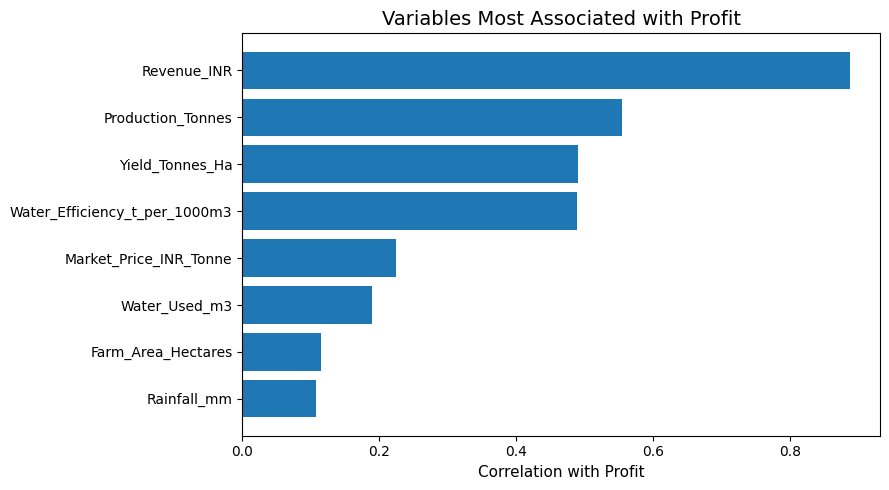

In [42]:
# Plot strongest absolute correlations with profit
corr_without_profit = correlation_with_profit.drop("Profit_INR")
top_corr = corr_without_profit.abs().sort_values(ascending=False).head(8)
plot_values = correlation_with_profit[top_corr.index].sort_values()

plt.figure(figsize=(9, 5))
plt.barh(plot_values.index, plot_values.values)
plt.xlabel("Correlation with Profit")
plt.title("Variables Most Associated with Profit")
plt.tight_layout()
plt.show()


## 10. Statistical testing

### One-way ANOVA

We test whether the mean outcome differs across **Kharif, Rabi and Zaid**.

- **H₀:** Mean outcome is the same across all seasons.
- **H₁:** At least one seasonal mean is different.
- Significance level: **α = 0.05**.

A significant p-value means there is evidence of a difference in means, but it does **not** by itself prove that season causes the difference.


In [43]:
# ANOVA: Profit across seasons
profit_groups = [
    group["Profit_INR"].dropna().values
    for _, group in clean_df.groupby("Season", observed=True)
]

profit_anova = stats.f_oneway(*profit_groups)

print("ANOVA for Profit")
print("F-statistic:", round(profit_anova.statistic, 4))
print("p-value:", profit_anova.pvalue)

if profit_anova.pvalue < 0.05:
    print("Result: Reject H0 — mean profit differs significantly across seasons.")
else:
    print("Result: Fail to reject H0.")


ANOVA for Profit
F-statistic: 34.2918
p-value: 1.7124156677360182e-15
Result: Reject H0 — mean profit differs significantly across seasons.


In [44]:
# ANOVA: Yield across seasons
yield_groups = [
    group["Yield_Tonnes_Ha"].dropna().values
    for _, group in clean_df.groupby("Season", observed=True)
]

yield_anova = stats.f_oneway(*yield_groups)

print("ANOVA for Yield")
print("F-statistic:", round(yield_anova.statistic, 4))
print("p-value:", yield_anova.pvalue)

if yield_anova.pvalue < 0.05:
    print("Result: Reject H0 — mean yield differs significantly across seasons.")
else:
    print("Result: Fail to reject H0 — evidence is insufficient to conclude a seasonal mean-yield difference.")


ANOVA for Yield
F-statistic: 1.458
p-value: 0.23283549440109827
Result: Fail to reject H0 — evidence is insufficient to conclude a seasonal mean-yield difference.


## 11. Automated key findings

In [45]:
# Generate findings directly from the analysis

best_profit_season = season_summary["Average_Profit"].idxmax()
worst_profit_season = season_summary["Average_Profit"].idxmin()

best_yield_season = season_summary["Average_Yield"].idxmax()
worst_yield_season = season_summary["Average_Yield"].idxmin()

best_irrigation = irrigation_summary["Average_Profit"].idxmax()
best_efficiency_irrigation = irrigation_summary["Water_Efficiency"].idxmax()
highest_water_irrigation = irrigation_summary["Average_Water"].idxmax()

print("KEY FINDINGS")
print("-" * 70)
print(f"1. Highest average profit: {best_profit_season} "
      f"(₹{season_summary.loc[best_profit_season, 'Average_Profit']:,.0f}).")

print(f"2. Lowest average profit: {worst_profit_season} "
      f"(₹{season_summary.loc[worst_profit_season, 'Average_Profit']:,.0f}).")

print(f"3. Highest average yield: {best_yield_season} "
      f"({season_summary.loc[best_yield_season, 'Average_Yield']:.2f} t/ha).")

print(f"4. Lowest average yield: {worst_yield_season} "
      f"({season_summary.loc[worst_yield_season, 'Average_Yield']:.2f} t/ha).")

print(f"5. Most profitable irrigation method: {best_irrigation} "
      f"(₹{irrigation_summary.loc[best_irrigation, 'Average_Profit']:,.0f} average profit).")

print(f"6. Highest water-efficiency method: {best_efficiency_irrigation} "
      f"({irrigation_summary.loc[best_efficiency_irrigation, 'Water_Efficiency']:.2f} t/1000 m³).")

print(f"7. Highest average water use: {highest_water_irrigation} "
      f"({irrigation_summary.loc[highest_water_irrigation, 'Average_Water']:,.0f} m³).")

print(f"8. Profit ANOVA p-value: {profit_anova.pvalue:.3e}.")
print(f"9. Yield ANOVA p-value: {yield_anova.pvalue:.3f}.")


KEY FINDINGS
----------------------------------------------------------------------
1. Highest average profit: Kharif (₹178,915).
2. Lowest average profit: Zaid (₹-24,805).
3. Highest average yield: Kharif (5.64 t/ha).
4. Lowest average yield: Zaid (4.67 t/ha).
5. Most profitable irrigation method: Drip (₹219,626 average profit).
6. Highest water-efficiency method: Rainfed (7.56 t/1000 m³).
7. Highest average water use: Flood (8,026 m³).
8. Profit ANOVA p-value: 1.712e-15.
9. Yield ANOVA p-value: 0.233.
